# Test ExoSignal using synthetic data

This tutorial shows how to:
- Create synthetic data using models
- Assign models and priors and sampling the posteriors
- Visualizing the results

Two cases are used:
1) Keplerian model with eccentricity and a quadratic trend
2) Quasi-periodic GP

In [1]:
%matplotlib widget

import sys, os
print(f"Python version: {os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from exosignal import ExoSignal
print("ExoSignal version:", ExoSignal.__version__)

import dynesty
print(f"Dynesty version: {dynesty.__version__}")

Python version: 3.10.14
ExoSignal version: 0.1
Dynesty version: 2.1.5


## Check available deterministic (mean) models and GP (covariance) kernels

In [2]:
from models import MeanModel
print("Available deterministic model classes:", MeanModel().av_models[0])
print("Available deterministic model names:", MeanModel().av_models[1])

from kernels import Kernels
print("\nAvailable GP kernel classes:", Kernels().av_kernels[0])
print("Available GP kernel names:", Kernels().av_kernels[1])

Available deterministic model classes: ['ConstModel' 'KepModel' 'QuadModel' 'SinModel' 'TrendModel']
Available deterministic model names: ['const' 'kep' 'quad' 'sin' 'trend']

Available GP kernel classes: ['ConstKernel' 'ES2Kernel' 'QPKernel' 'SEKernel']
Available GP kernel names: ['constgp' 'es2gp' 'qpgp' 'segp']


# 1. Model keplerian with eccentricity and a quadratic trend

## Create synthetic data

std(y)      = 0.4933744469022441
mean(y_err) = 0.5029529234045076
Parameters for keplerian model: ['k', 'per', 'ecc', 'tc', 'w']
Parameters for quadratic model: ['a']


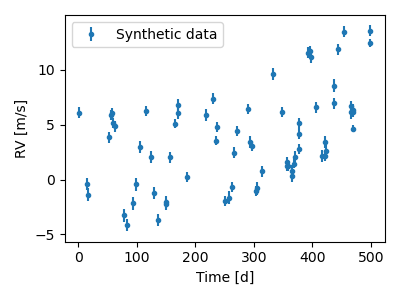

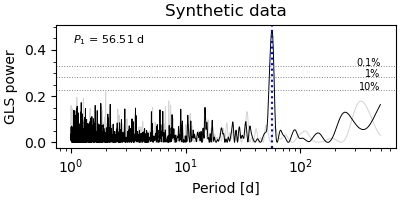

In [3]:
np.random.seed(123456)
tmin = 0
tmax = 500
n = 70

# Create synthetic times
t = np.linspace(tmin, tmax, 20000)
t = np.random.choice(t, size=n, replace=False)
t = np.sort(t)

y = np.zeros_like(t)
y_err = np.zeros_like(t)
instr = np.array(['SYNTH']*len(t))

# Add white noise
sigma_wn = 0.5
y_err += sigma_wn * (1 + np.random.normal(0.0, 0.1, t.size))
y += np.random.normal(0.0, sigma_wn, t.size)

print("std(y)      =", np.std(y))
print("mean(y_err) =", np.mean(y_err))

# Add keplerian signal
from models import KepModel
print("Parameters for keplerian model:", KepModel()._keys)
# Make parameters dictionary and add keplerian to data
params = dict(k=5, per=56, ecc=0.12, w=0.7, tc=70)
y += KepModel().compute(t, params)

# Add quadratic trend
from models import QuadModel
print("Parameters for quadratic model:", QuadModel()._keys)
y += QuadModel().compute(t, dict(a=0.00004))



plt.figure(figsize=(4, 3))
plt.errorbar(t, y, yerr=y_err, fmt='.', label='Synthetic data')
plt.xlabel('Time [d]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.tight_layout()
plt.show()

from periodogram import Periodogram
Periodogram.plot(t, y, y_err, pmin=1, maxper_show=2, title='Synthetic data')

## Construct the model with priors and sample the model parameters

In [4]:
run_this = True


# ============================
# DataFrame:
# ============================
# A DataFrame (DF) with time, dataset + error and instrument of each observation is required for ExoSignal
# If two dataset are modelled, include the second dataset in the DF (using the same time stamp).
# Instruments can be different: e.g. the RV dataset can use HARPS03 and HARPS15 while the activity (e.g. S-index) only uses HARPS (not affected by fiber change).
# In that case, 'instr' column will have 'HARPS03' and 'HARPS15' for the RV dataset while 'HARPS' is the 'ref_instr' (str) input of ExoSignal class and is used for the activity dataset, which will include all 'times' of the DF.
import pandas as pd
df = pd.DataFrame({'t': t, 'rv': y, 'rv_err': y_err, 'instr': instr})
display(df.head())


# ============================
# Configuration:
# ============================
exo_options = dict(
    datasets    = ['rv'],
    use_offsets = [False],  # if True, an offset parameter is added for each dataset (except the reference instrument) and the prior is set to ['uniform', -100, 100] by default. To change the prior of the offset parameters, use the keys 'y1_mu_{instr}' in the priors dictionary, where {instr} is the name of the instrument as it appears in the 'instr' column of the DF.
    key_t       = 't',      # The DF column name of the time variable (default ia 'bjd).
    key_err     = '_err',   # The uncertainties suffix to be added to the dataset id to access the error column (default is '_err').
    ref_instr   = "SYNTH"
)
dyn_options = dict(
    nlive     = 500,
    walks_c   = 2,                # For more info about nlive see https://dynesty.readthedocs.io/en/v3.0.0/faq.html#live-point-questions
    save_path = 'synth_test_ecc', # A new directory is automatically created if does not exist. If it already exists, the results will be overwritten.
    verb      = True,
)


# ============================
# Priors dictionary:
# ============================
priors = dict(
    y1_kep_per_1  = ['loguniform', 1, (df.t.max() - df.t.min())/2],
    y1_kep_k_1    = ['loguniform', 0.01, 100],
    #y1_kep_ecc_1  = ['fixed', 0],     # if fixed eccentricity model
    #y1_kep_w_1    = ['fixed', np.pi], # if fixed eccentricity model
    y1_kep_ecc_1  = ['beta', 0.867, 3.03],
    y1_kep_w_1    = ['uniform', 0, 2*np.pi],
    y1_kep_tc_1   = ['tc_prior'],

    #y1_trend_slope_1 = ['uniform', -1, 1], # if fitting a linear model
    y1_quad_a_1 = ['uniform', -0.01, 0.01], # fit quadratic model

    y1_jit_SYNTH = ['uniform', 0.0, 10],
)


if run_this:
    model = ExoSignal(df, priors, **exo_options)
    model.run_dynesty(**dyn_options)
    model.save_results()

,t,rv,rv_err,instr
0,2.125106,6.074031,0.504232,SYNTH
1,15.150758,-0.390043,0.530365,SYNTH
2,17.450873,-1.376093,0.568327,SYNTH
3,52.027601,3.833545,0.470202,SYNTH
4,56.177809,5.874644,0.423282,SYNTH



ExoSignal v0.1 configuration
Data
-------------------------------------------------------
Nobs		= 70
Datasets	= y1: rv
Instruments	= y1: SYNTH
-------------------------------------------------------
Models
-------------------------------------------------------
Det. Models	= y1: ConstModel, KepModel, QuadModel
Det. Parameters	= y1: y1_mu_SYNTH, y1_kep_k_1, y1_kep_per_1, y1_kep_ecc_1, y1_kep_tc_1, y1_kep_w_1, y1_quad_a_1
-------------------------------------------------------
Priors
-------------------------------------------------------
y1_kep_per_1	= LogUniformPrior(lo=1, hi=248.5624281214061)
y1_kep_k_1	= LogUniformPrior(lo=0.01, hi=100)
y1_kep_ecc_1	= BetaPrior(a=0.867, b=3.03)
y1_kep_w_1	= UniformPrior(lo=0, hi=6.283185307179586)
y1_kep_tc_1	= TcPrior()
y1_quad_a_1	= UniformPrior(lo=-0.01, hi=0.01)
y1_jit_SYNTH	= UniformPrior(lo=0.0, hi=10)
y1_mu_SYNTH	= UniformPrior(lo=-4.176606214070005, hi=13.53257485393468)
-------------------------------------------------------
 Dynesty confi

31258it [06:07, 84.98it/s, batch: 4 | bound: 33 | nc: 1 | ncall: 473843 | eff(%):  6.494 | loglstar: -57.781 < -50.821 < -52.558 | logz: -95.174 +/-  0.227 | stop:  0.924]                 


ESS: 10827.899625160766
Results
-------------------------------------------------------
Runtime		= 0:06:08.002656
lnZ		= -95.16 +/- 0.20
-------------------------------------------------------
Median posteriors
-------------------------------------------------------
y1_kep_per_1	= 56.0109 (+0.0227 -0.0650)
y1_kep_k_1	= 5.1438 (+0.0348 -0.0945)
y1_kep_ecc_1	= 0.1080 (+0.0062 -0.0177)
y1_kep_w_1	= 0.6696 (+0.0628 -0.1789)
y1_kep_tc_1	= 294.1908 (+0.1171 -0.3240)
y1_quad_a_1	= 0.0000 (+0.0000 -0.0000)
y1_jit_SYNTH	= 0.1884 (+0.0393 -0.1172)
y1_mu_SYNTH	= 0.0283 (+0.0381 -0.1065)


## Plotting the results

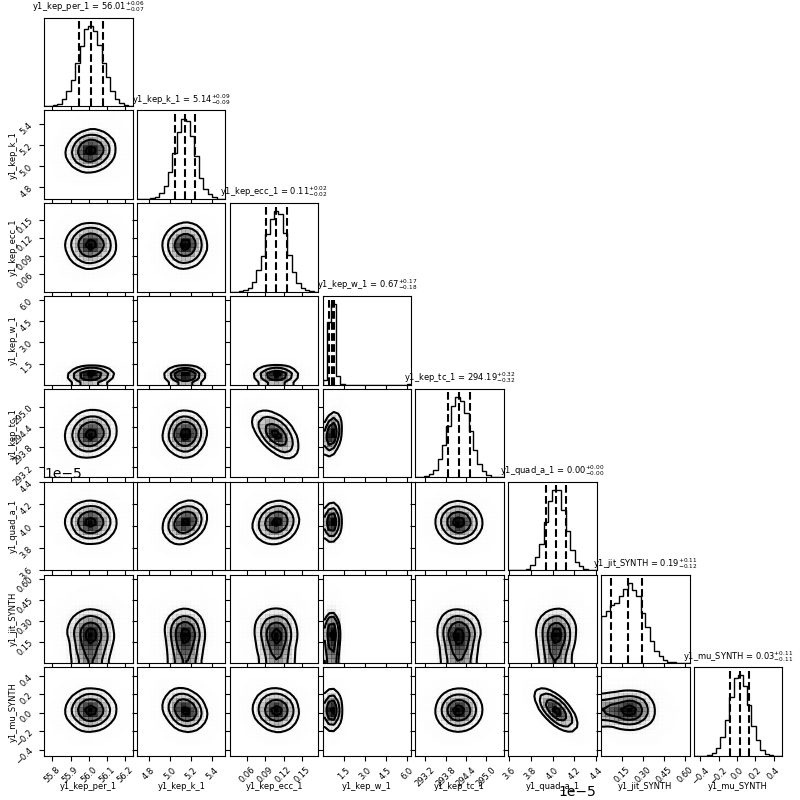

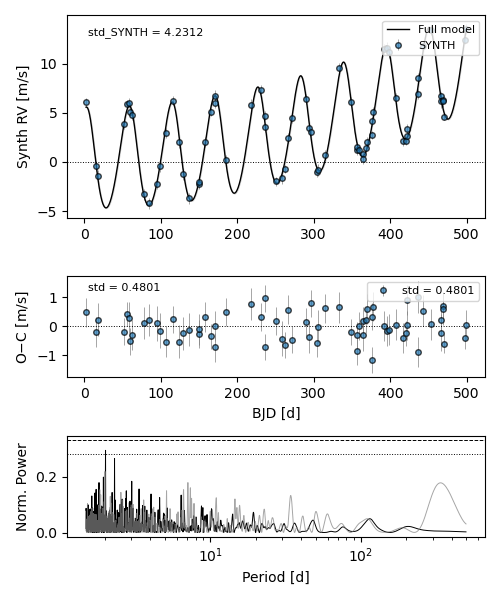

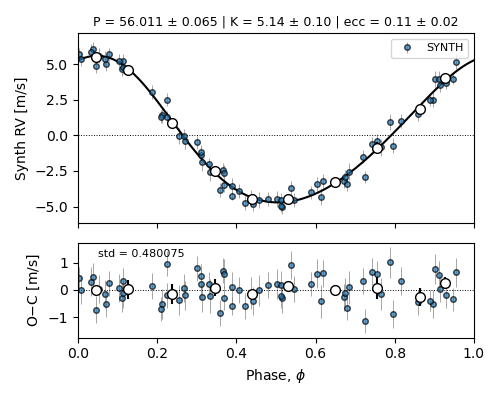

In [5]:
results = ExoSignal.load_results(dyn_options['save_path'])

# Corner plot
ExoSignal.corner_plot(results['posteriors'], save_path=dyn_options['save_path'], show=True)

plotting = ExoSignal.plot(results, save_path=dyn_options['save_path'])
plotting.full_model(save_plot=True, show_gp=False, y_labels=['Synth RV'], y_units=['[m/s]'], x_label='BJD [d]')
plotting.phase(save_plot=True, show_binned=True, y_labels=['Synth RV'], y_units=['[m/s]'], x_label='Phase, $\phi$')

# 2. Model quasi-periodic signal with a GP

## Create synthetic data using ExoSignal models

std(y)      = 0.5573679485373594
mean(y_err) = 0.501276979114167
Parameters for QP kernel: ['eta1', 'eta2', 'eta3', 'eta4']


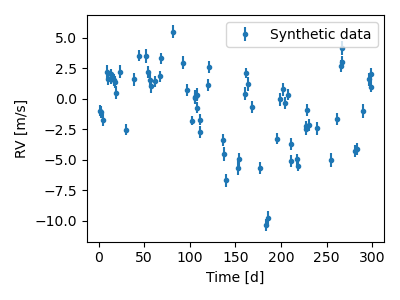

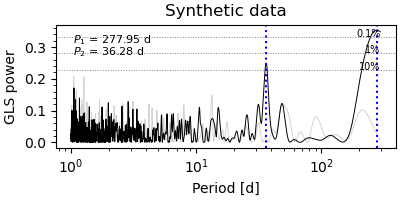

,t,rv,rv_err,instr
0,1.950098,-0.977744,0.468952,SYNTH
1,2.685134,-1.105466,0.488384,SYNTH
2,4.935247,-1.768490,0.487522,SYNTH
3,9.090455,2.212963,0.576570,SYNTH
4,9.975499,1.586544,0.438686,SYNTH


In [6]:
np.random.seed(12345)
tmin = 0
tmax = 300
n = 70

# Create synthetic times
t = np.linspace(tmin, tmax, 20000)
t = np.random.choice(t, size=n, replace=False)
t = np.sort(t)

y = np.zeros_like(t)
y_err = np.zeros_like(t)
instr = np.array(['SYNTH']*len(t))

# Add white noise
sigma_wn = 0.5
y_err += sigma_wn * (1 + np.random.normal(0.0, 0.1, t.size))
y += np.random.normal(0.0, sigma_wn, t.size)

print("std(y)      =", np.std(y))
print("mean(y_err) =", np.mean(y_err))


# Add QPGP noise
from gp_model import sample_prior
from kernels import QPKernel
print("Parameters for QP kernel:", QPKernel()._keys)
params = dict(eta1=3, eta2=70, eta3=40, eta4=0.4, mu=0, jit=0.01)

X = t[:, None] # GPs expect 2D input, so we reshape t to be a column vector

y_sample = sample_prior(1, params, X, QPKernel().compute, jitter=0.01, mean_f=None, show_plot=False)
y += y_sample.flatten()  # Flatten to 1D array



plt.figure(figsize=(4, 3))
plt.errorbar(t, y, yerr=y_err, fmt='.', label='Synthetic data')
plt.xlabel('Time [d]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.tight_layout()
plt.show()


from periodogram import Periodogram
Periodogram.plot(t, y, y_err, pmin=1, maxper_show=2, title='Synthetic data')

import pandas as pd
df = pd.DataFrame({'t': t, 'rv': y, 'rv_err': y_err, 'instr': instr})
display(df.head())

## Run the GP model

In [7]:
run_this = False

# Options:
datasets = ['rv']
use_offsets = [False]
verb = True
nlive = 1000 # For more info about nlive see https://dynesty.readthedocs.io/en/v3.0.0/faq.html#live-point-questions
save_path = 'synth_test_gp' # A new directory is automatically created if does not exist. If it already exists, the results will be overwritten.
# --------


# Priors dictionary:
priors = dict(
    y1_qpgp_eta1_1 = ['loguniform', 0.01, 10],
    #y1_qpgp_eta2_1 = ['uniform', 1, 2000],
    y1_qpgp_eta2_1 = ['per_cond', 0.5, 4], # prior on eta2 that depends on eta3, so that eta2 is between 0.5 and 4 times eta3
    y1_qpgp_eta3_1 = ['loguniform', 1, df.t.max() - df.t.min()],
    y1_qpgp_eta4_1 = ['loguniform', 0.1, 3],

    #y1_jit_SYNTH = ['uniform', 0.01, 10], # just to show how to change the hidden jitter prior hardcoded into ExoSignal class
)


if run_this:
    model = ExoSignal(df, priors, datasets=datasets, use_offsets=use_offsets, key_t='t', ref_instr="SYNTH")
    model.run_dynesty(nlive=nlive, walks_c=3, save_path=save_path, verb=verb)
    model.save_results()

## Plotting the results

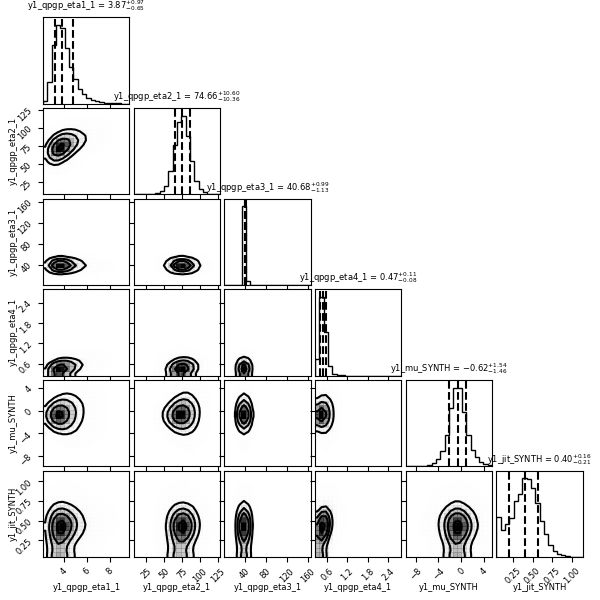

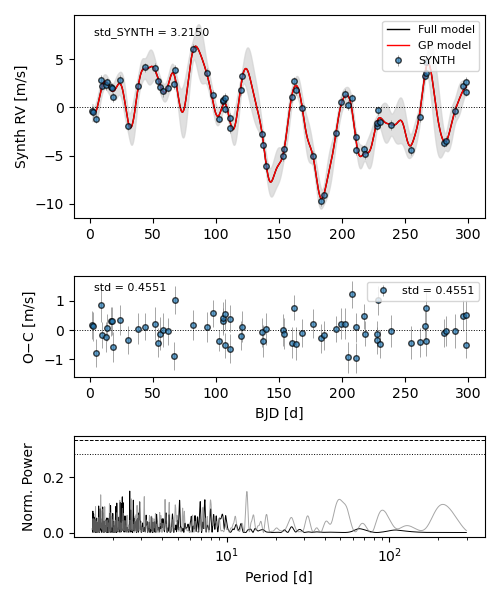

In [8]:
results = ExoSignal.load_results(save_path)

# Corner plot
ExoSignal.corner_plot(results['posteriors'], save_path=save_path, show=True)

plotting = ExoSignal.plot(results, save_path=save_path)
plotting.full_model(save_plot=True, show_gp=True, y_labels=['Synth RV'], y_units=['[m/s]'], x_label='BJD [d]')
plotting.phase(save_plot=True, show_binned=True, y_labels=['Synth RV'], y_units=['[m/s]'], x_label='Phase, $\phi$')

## Accessing the models and results using the $\verb+results+$ dictionary

dict_keys(['lnZ', 'lnZ_err', 'posteriors', 'post_med', 'mean_models_ds', 'kernels_ds', 'instr_ds', 'datasets', 'df', 'key_t', 'key_instr', 'key_err'])
Datasets used: {'y1': 'rv'}
GP kernels used: ['QPKernel']
['QPKernel'] ['y1_qpgp_eta1_1' 'y1_qpgp_eta2_1' 'y1_qpgp_eta3_1' 'y1_qpgp_eta4_1']
Full model dictionary keys: ['y_center', 'full_model', 'residuals', 'full_model_i', 'ti_i']


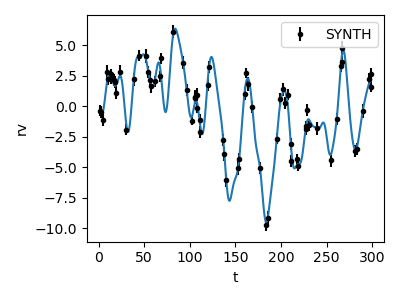

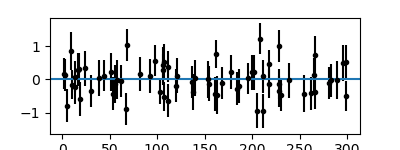

In [9]:
print(results.keys())
print("Datasets used:", results['datasets'])
print("GP kernels used:", results['kernels_ds']['y1'][0].get_kernel_names())
print(results['kernels_ds']['y1'][0].get_kernel_names(), results['kernels_ds']['y1'][0].get_kernel_keys())

model = plotting._make_full_model_dataset('y1')
print("Full model dictionary keys:", list(model.keys()))



plt.figure(figsize=(4, 3))
plt.errorbar(df.t, model['y_center'], df.rv_err, fmt='k.', label=np.unique(results['instr_ds']['y1'])[0])
plt.plot(model['ti_i'], model['full_model_i'])
plt.xlabel(results['key_t'])
plt.ylabel(results['datasets']['y1'])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 1.5))
plt.errorbar(df.t, model['residuals'], df.rv_err, fmt='k.')
plt.axhline(0)
plt.show()